In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Standard library
import gc
import warnings

# Third‑party libraries
import dask
import dask.array as da
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster, wait
from dask_cuda import LocalCUDACluster
import numpy as np
import pandas as pd
import xgboost.dask as dxgb

# Local application imports
from newutils.data.datasets import (
    add_lags,
    load_train_subset,
    load_train_subset_fixed_per_file,
)
from newutils.other.helpers import init_context
from oldutils.datasets import (
    ARTIFACTS_FOLDER,
    STATIC_FEATURES,
    HydroStaticFeaturesFiles,
)
from oldutils.types import TimeRange

init_context()

In [3]:
HORIZON_HISTORY = TimeRange.YEAR
HORIZON_FORECAST = TimeRange.WEEK
PARTITION_SIZE = "500MB"

COL_GAUGE_ID = "gauge_id"
TARGETS = ["q_mm_day"]

In [4]:
cluster = LocalCluster(
    dashboard_address=":8789", asynchronous=False, n_workers=2, threads_per_worker=1
)
client = Client(cluster)
# cluster = LocalCUDACluster(
#     CUDA_VISIBLE_DEVICES="0",
#     # n_workers=1,
#     # threads_per_worker=1,
#     dashboard_address=":8789",
# )

2025-05-07 12:29:06,398 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 932008c7a671cb48250a69ea44c7b003 initialized by task ('shuffle-transfer-932008c7a671cb48250a69ea44c7b003', 999) executed on worker tcp://127.0.0.1:33233
2025-05-07 12:29:43,174 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 932008c7a671cb48250a69ea44c7b003 deactivated due to stimulus 'task-finished-1746620983.17225'


In [5]:
NUM_LOAD = None
ROWS_PER_FILE = 50
df = load_train_subset_fixed_per_file(NUM_LOAD, HORIZON_HISTORY + ROWS_PER_FILE)
df = client.persist(df)
wait(df)

DoneAndNotDoneFutures(done={<Future: finished, type: pandas.core.frame.DataFrame, key: ('sort_index-65bb69c000ee7a7f5db8ae29a743a37d', 643)>, <Future: finished, type: pandas.core.frame.DataFrame, key: ('sort_index-65bb69c000ee7a7f5db8ae29a743a37d', 487)>, <Future: finished, type: pandas.core.frame.DataFrame, key: ('sort_index-65bb69c000ee7a7f5db8ae29a743a37d', 965)>, <Future: finished, type: pandas.core.frame.DataFrame, key: ('sort_index-65bb69c000ee7a7f5db8ae29a743a37d', 270)>, <Future: finished, type: pandas.core.frame.DataFrame, key: ('sort_index-65bb69c000ee7a7f5db8ae29a743a37d', 839)>, <Future: finished, type: pandas.core.frame.DataFrame, key: ('sort_index-65bb69c000ee7a7f5db8ae29a743a37d', 373)>, <Future: finished, type: pandas.core.frame.DataFrame, key: ('sort_index-65bb69c000ee7a7f5db8ae29a743a37d', 286)>, <Future: finished, type: pandas.core.frame.DataFrame, key: ('sort_index-65bb69c000ee7a7f5db8ae29a743a37d', 903)>, <Future: finished, type: pandas.core.frame.DataFrame, key: (

In [6]:
targets = []

lags = range(1, HORIZON_HISTORY + 1)
lags_columns = ["prcp", "t_max", "t_min", "t_mean", "lvl_sm"]  # + ["q_mm_day"]
df = add_lags(df, lags_columns, lags)

target_lags = range(1, range(1, HORIZON_FORECAST + 1))
df = add_lags(df, targets, target_lags, targets)
targets.extend(TARGETS)

TypeError: 'range' object cannot be interpreted as an integer

In [ ]:
df = df.dropna()
df = client.persist(df)
wait(df)


In [ ]:
df = df.repartition(partition_size=PARTITION_SIZE)
df = client.persist(df)
wait(df)

In [ ]:
res = client.compute(df.shape[0])
wait(res)
res.result()

2144

In [ ]:
hsff = (
    HydroStaticFeaturesFiles()
    .dataframe.collect()
    .to_pandas()[STATIC_FEATURES + ["gauge_id"]]
)
hsff = dd.from_pandas(hsff)
df = df.merge(hsff, how="left", on="gauge_id")
df = df.repartition(partition_size=PARTITION_SIZE)
df = client.persist(df)
wait(df)

In [ ]:
dd.to_parquet(df, ARTIFACTS_FOLDER / f"v{ROWS_PER_FILE}_samples_df.parquet")

In [ ]:
X = df.drop(columns=set(lags_columns + targets + ["date"]))
y = df[targets]
X_train, y_train = X, y

# Model

In [ ]:
gc.collect()
print("Prepare datasets...")
with warnings.catch_warnings(record=False) as caught_warnings:
    X_trainp = client.persist(X_train)
    wait(X_trainp)
    y_trainp = client.persist(y_train)
    wait(y_trainp)
gc.collect()

Prepare datasets...


21

In [ ]:
print("Create train set...")
X_s, y_s = X_trainp, y_trainp
dtrain = dxgb.DaskDMatrix(client, X_s, y_s)
gc.collect()

Create train set...


214

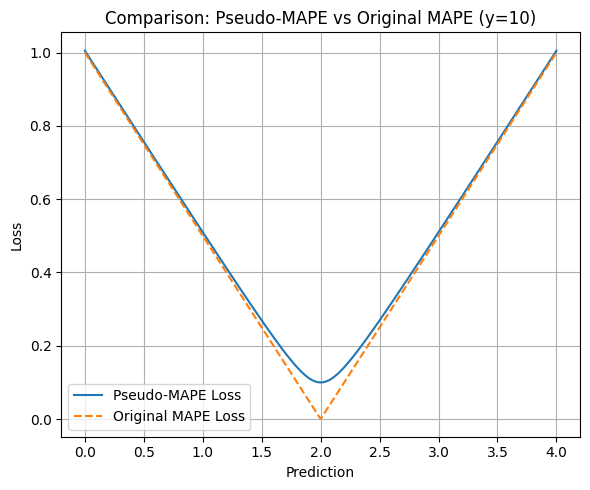

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def pseudo_mape_loss(preds, y, delta=1e-1):
    delta_2 = delta * delta
    eps = 1e-9
    y_safe = np.where(y == 0, eps, y)
    r = (preds - y) / y_safe
    return np.sqrt(r**2 + delta_2)


def original_mape_loss(preds, y):
    eps = 1e-9
    y_safe = np.where(y == 0, eps, y)
    return np.abs(preds - y) / y_safe


y_true = 2.0
preds = np.linspace(0, 4, 500)
pseudo_loss = pseudo_mape_loss(preds, y_true)
orig_loss = original_mape_loss(preds, y_true)

plt.figure(figsize=(6, 5))
plt.plot(preds, pseudo_loss, label="Pseudo-MAPE Loss")
plt.plot(preds, orig_loss, label="Original MAPE Loss", linestyle="--")
plt.xlabel("Prediction")
plt.ylabel("Loss")
plt.title("Comparison: Pseudo-MAPE vs Original MAPE (y=10)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
params = {
    "tree_method": "hist",
    # 'device': 'cuda',
    "learning_rate": 0.001,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 1,
    # "objective": "reg:squarederror",
    "eval_metric": "mape",
}


def pseudo_mape_obj(preds, dtrain, delta=1e-1):
    delta_2 = delta * delta
    eps = 1e-9

    y = dtrain.get_label()
    y_safe = np.where(y == 0, eps, y)

    r = (preds - y) / y_safe
    denom = np.sqrt(r * r + delta_2)
    grad = (r / denom) / y_safe
    hess = (delta_2 / (denom**3)) / (y_safe * y_safe)

    return grad, hess


def main(client):
    gc.collect()
    results = dxgb.train(
        client,
        params,
        dtrain,
        num_boost_round=1000,
        verbose_eval=50,
        evals=[(dtrain, "train")],
        obj=pseudo_mape_obj,
    )
    gc.collect()

    print("Save model...")
    results["booster"].save_model(ARTIFACTS_FOLDER / "test_save.json")

    print("Training metrics and booster information:")
    print(results["history"])
    print(results["booster"])
    gc.collect()
    return results


result = main(client)

[12:10:10] Task [xgboost.dask-1]:tcp://127.0.0.1:38737 got rank 0
[12:10:12] [0]	train-mape:15.95780
[12:10:22] [50]	train-mape:3.91023
[12:10:32] [100]	train-mape:3.26124
[12:10:42] [150]	train-mape:3.08059
[12:10:52] [200]	train-mape:2.77663
[12:11:04] [250]	train-mape:2.76938
[12:11:14] [300]	train-mape:2.75101
[12:11:25] [350]	train-mape:2.81018
[12:11:35] [400]	train-mape:3.27089
[12:11:46] [450]	train-mape:2.79807
[12:12:00] [500]	train-mape:2.20230
[12:12:11] [550]	train-mape:2.15210
[12:12:27] [600]	train-mape:2.14474
[12:12:41] [650]	train-mape:1.93925
[12:12:51] [700]	train-mape:1.99681
[12:13:01] [750]	train-mape:1.87567
[12:13:12] [800]	train-mape:1.79471
[12:13:22] [850]	train-mape:1.60695
[12:13:33] [900]	train-mape:1.51327
[12:13:44] [950]	train-mape:1.48649
[12:13:58] [999]	train-mape:1.45649


Save model...
Training metrics and booster information:
{'train': OrderedDict([('mape', [15.957795430674501, 12.535346400028867, 7.522158008734265, 9.930101621105644, 7.672314098776442, 13.125313762649307, 11.141285296447203, 8.319879398796132, 6.9261805341763525, 5.81230791744356, 6.0111175501383585, 5.166553446025318, 5.347593714549489, 5.242671770679706, 5.083688555430053, 4.763403268277053, 4.63297374005145, 4.540876412169518, 4.447712383330517, 4.734530330128978, 4.72363224989931, 4.802797684013112, 4.562817041317743, 4.475511424016973, 5.014536623506827, 4.708535883821214, 4.722425590733762, 4.734084760194098, 4.506637117216983, 4.454948193248074, 4.334952353163643, 4.483740989248425, 4.194320766261639, 4.031990350120911, 4.194933392217576, 4.141914304884539, 4.051188338254979, 4.020667024688091, 4.109886313296434, 4.007666251701796, 4.466371522906188, 3.988185079843612, 4.094658066056229, 3.9022991839571404, 3.8423612514635255, 3.860590373593585, 3.873358012222606, 3.87504873927

In [ ]:
# client.close()
# cluster.close()
# gc.collect()

In [ ]:
import polars as pl


PATH_MERGED_DATASETS = ARTIFACTS_FOLDER / "merged_datasets"
FILENAME_TRAIN_IDS = "train_file_ids.csv"
COL_GAUGE_ID = "gauge_id"

train_df = pl.read_csv(PATH_MERGED_DATASETS / FILENAME_TRAIN_IDS)
file_ids = train_df["file_id"].to_list()[0:1]
paths = [PATH_MERGED_DATASETS / f"{file_id}.parquet" for file_id in file_ids]
df_test = dd.read_parquet(paths)
lags = range(1, HORIZON_HISTORY + 1)

lags_columns = ["prcp", "t_max", "t_min", "t_mean", "lvl_sm"]  # + ["q_mm_day"]
df_test = add_lags(df_test, lags_columns, lags)

targets = []
df_test = add_lags(df_test, targets, range(1, HORIZON_FORECAST + 1), targets)
targets.extend(TARGETS)

df_test = df_test.dropna()
hsff = (
    HydroStaticFeaturesFiles()
    .dataframe.collect()
    .to_pandas()[STATIC_FEATURES + ["gauge_id"]]
)
hsff = dd.from_pandas(hsff)
df_test = df_test.merge(hsff, how="left", on="gauge_id")
df_test = df_test.repartition(partition_size=PARTITION_SIZE)
df_test = client.persist(df_test)
wait(df_test)

/home/khuzin/.cache/pypoetry/virtualenvs/pro-1-experiments-jmzHMVzz-py3.11/lib/python3.11/site-packages/dask/dataframe/multi.py:521: UserWarning: Merging dataframes with merge column data type mismatches: 
+--------------------------+------------+-------------+
| Merge columns            | left dtype | right dtype |
+--------------------------+------------+-------------+
| ('gauge_id', 'gauge_id') | int32      | int64       |
+--------------------------+------------+-------------+
Cast dtypes explicitly to avoid unexpected results.
  warnings.warn(


DoneAndNotDoneFutures(done={<Future: finished, type: pandas.core.frame.DataFrame, key: ('repartitionsize-4cb49a718585d71f46bb016e52fd4ff0', 0)>}, not_done=set())

In [ ]:
X_test = df_test.drop(columns=set(lags_columns + targets + ["date"])).compute()

In [ ]:
X_test = X.compute()

In [ ]:
import xgboost as xgb
import shap

booster = xgb.Booster()

booster.load_model(ARTIFACTS_FOLDER / "test_save.json")

# dtest = xgb.DMatrix(data=X_train)
# preds = booster.predict(dtest)

explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test)

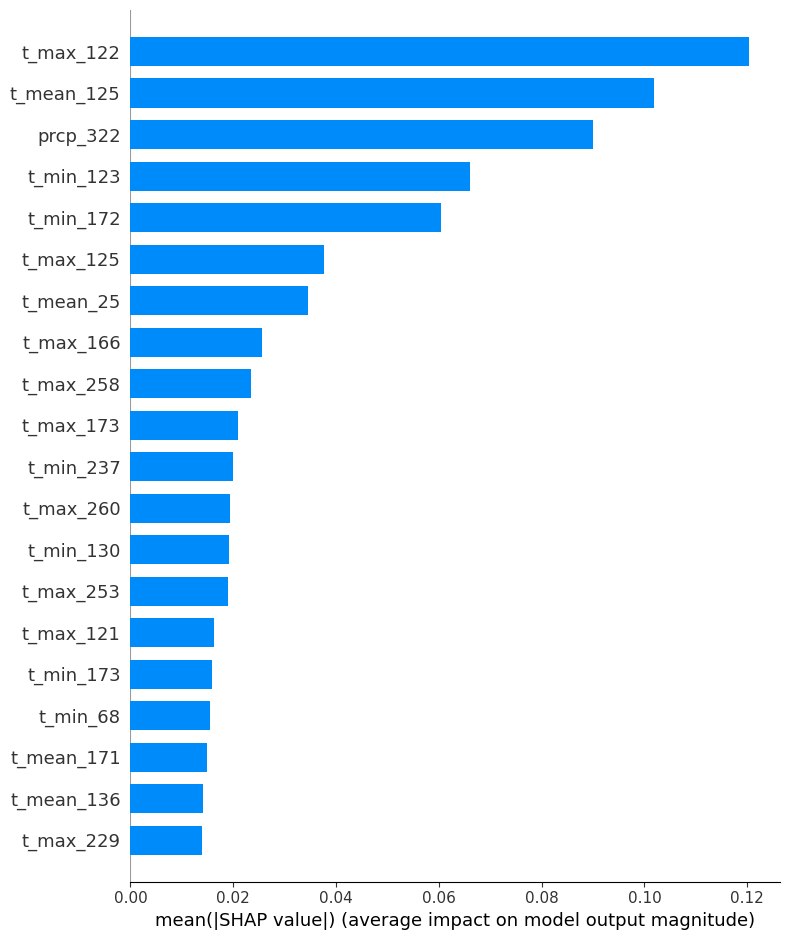

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

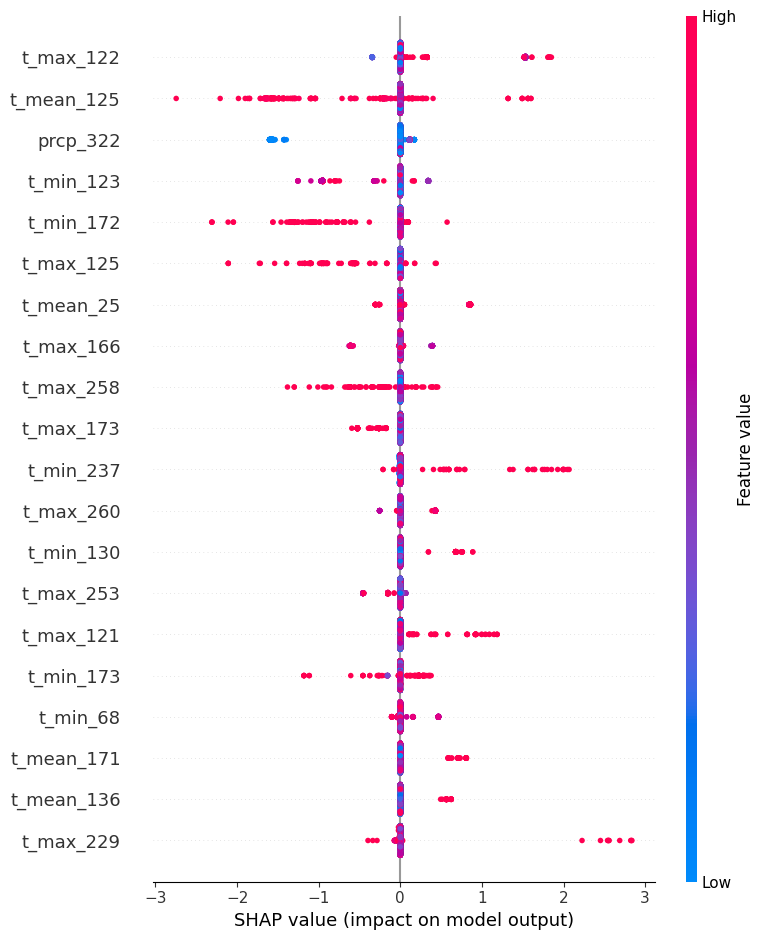

In [ ]:
shap.summary_plot(shap_values, X_test)

In [ ]:
X_test

,gauge_id,prcp_1,prcp_2,prcp_3,prcp_4,prcp_5,prcp_6,prcp_7,prcp_8,prcp_9,...,gwt_cm_sav,lkv_mc_usu,rev_mc_usu,sgr_dk_sav,slp_dg_sav,ws_area,ele_mt_sav,height_bs,lat,lon
0,1151,1.548065,16.491732,1.837655,4.528510,3.222448,0.197883,0.016806,0.370735,2.551143,...,444.781948,0.000963,0.0,129.339747,12.291630,3880.404,845.535183,556.52,61.14041,149.65827
1,1151,0.243814,1.548065,16.491732,1.837655,4.528510,3.222448,0.197883,0.016806,0.370735,...,444.781948,0.000963,0.0,129.339747,12.291630,3880.404,845.535183,556.52,61.14041,149.65827
0,1556,0.999807,8.089939,0.912963,1.082318,7.203279,0.920919,0.330668,0.250658,0.480532,...,322.249709,0.000000,0.0,179.071300,15.356518,595.920,671.439029,252.60,60.08420,150.89138
1,1556,0.060131,0.999807,8.089939,0.912963,1.082318,7.203279,0.920919,0.330668,0.250658,...,322.249709,0.000000,0.0,179.071300,15.356518,595.920,671.439029,252.60,60.08420,150.89138
0,1566,2.762287,16.511743,4.284459,9.041108,7.648246,0.365124,0.017706,0.093093,0.683724,...,154.874794,11.195579,0.0,95.238418,7.442899,24593.533,348.661300,13.04,59.75644,148.64612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,84447,3.386528,0.544764,0.590619,1.713384,0.575281,1.470948,20.325778,2.634874,10.213716,...,863.869198,0.000000,0.0,746.536869,27.908684,875.223,2571.552397,972.20,42.85000,44.05000
0,84448,0.277980,0.185380,0.147396,0.191953,0.315890,4.109560,1.786467,3.568724,0.030307,...,712.754695,0.000000,0.0,718.135567,23.666734,401.454,2110.120846,668.47,43.01000,44.56000
1,84448,3.094005,0.277980,0.185380,0.147396,0.191953,0.315890,4.109560,1.786467,3.568724,...,712.754695,0.000000,0.0,718.135567,23.666734,401.454,2110.120846,668.47,43.01000,44.56000
0,84449,0.261482,0.244224,0.405525,0.239975,0.558901,7.840465,1.907217,6.002735,0.025995,...,921.854147,0.004966,0.0,874.129020,28.665490,227.474,2565.727318,1197.52,42.83000,44.30000
